[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3010192-advanced-simulation/blob/main/assignments/assignment5-random-variable-generation.ipynb)

# 1. Desarrollo del generador de la variable aleatoria X

El objetivo de esta tarea es generar observaciones de una variable aleatoria continua $X$, cuya función de densidad está definida por tramos. Como el enunciado solo asigna densidad en el intervalo $[0,7)$, se interpreta que ese es el soporte de la variable aleatoria y que la densidad es cero fuera de dicho intervalo:

$$
f(x)=
\begin{cases}
\frac{1}{6}, & 0 \le x < 2 \\
\frac{1}{3}, & 2 \le x < 3 \\
\frac{1}{12}, & 3 \le x < 7 \\
0, & \text{fuera del soporte } [0,7)
\end{cases}
$$

Para generar valores de $X$, se utilizará el método de la transformada inversa. Este método parte de un número pseudoaleatorio uniforme

$$
U \sim \text{Uniforme}(0,1)
$$

y calcula

$$
X = F^{-1}(U),
$$

donde $F$ es la función de distribución acumulada de $X$.

Primero se verifica que $f(x)$ es una función de densidad válida:

- $f(x) \ge 0$ para todo $x$, porque todos los valores de la densidad son positivos o cero.
- El área total bajo la curva debe ser igual a 1:

$$
\int_0^2 \frac{1}{6}\, dx + \int_2^3 \frac{1}{3}\, dx + \int_3^7 \frac{1}{12}\, dx
= \frac{2}{6}+\frac{1}{3}+\frac{4}{12}
= \frac{1}{3}+\frac{1}{3}+\frac{1}{3}=1
$$

Por lo tanto, $f(x)$ sí es una función de densidad válida.

La función de distribución acumulada se obtiene integrando por tramos:

$$
F(x)=
\begin{cases}
0, & x < 0 \\
\frac{x}{6}, & 0 \le x < 2 \\
\frac{1}{3}+\frac{x-2}{3}, & 2 \le x < 3 \\
\frac{2}{3}+\frac{x-3}{12}, & 3 \le x < 7 \\
1, & x \ge 7
\end{cases}
$$

De forma equivalente:

$$
F(x)=
\begin{cases}
0, & x < 0 \\
\frac{x}{6}, & 0 \le x < 2 \\
\frac{x}{3}-\frac{1}{3}, & 2 \le x < 3 \\
\frac{x}{12}+\frac{5}{12}, & 3 \le x < 7 \\
1, & x \ge 7
\end{cases}
$$

Ahora se despeja $x$ en cada tramo para obtener la función inversa. Como $u=F(x)$, se resuelve la ecuación correspondiente en cada intervalo:

Para $0 \le x < 2$:

$$
u=\frac{x}{6} \quad \Rightarrow \quad x=6u
$$

Este tramo corresponde a $0 \le u < 1/3$.

Para $2 \le x < 3$:

$$
u=\frac{x}{3}-\frac{1}{3} \quad \Rightarrow \quad 3u=x-1 \quad \Rightarrow \quad x=3u+1
$$

Este tramo corresponde a $1/3 \le u < 2/3$.

Para $3 \le x < 7$:

$$
u=\frac{x}{12}+\frac{5}{12} \quad \Rightarrow \quad 12u=x+5 \quad \Rightarrow \quad x=12u-5
$$

Este tramo corresponde a $2/3 \le u \le 1$.

Por lo tanto, la función inversa queda definida por tramos de la siguiente forma:

$$
F^{-1}(u)=
\begin{cases}
6u, & 0 \le u < \frac{1}{3} \\
3u+1, & \frac{1}{3} \le u < \frac{2}{3} \\
12u-5, & \frac{2}{3} \le u \le 1
\end{cases}
$$

Esta expresión permite construir directamente el generador de observaciones de la variable aleatoria $X$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 20260428
rng = np.random.default_rng(RANDOM_SEED)

plt.style.use("default")

In [2]:
intervals = pd.DataFrame({
    "Intervalo": ["[0, 2)", "[2, 3)", "[3, 7)"],
    "Densidad": [1/6, 1/3, 1/12],
    "Longitud": [2, 1, 4]
})

intervals["Área"] = intervals["Densidad"] * intervals["Longitud"]
total_area = intervals["Área"].sum()
all_non_negative = (intervals["Densidad"] >= 0).all()

print("Verificación de la función de densidad")
print(f"Todas las densidades son no negativas: {all_non_negative}")
print(f"Área total bajo la curva: {total_area:.6f}")

intervals

Verificación de la función de densidad
Todas las densidades son no negativas: True
Área total bajo la curva: 1.000000


,Intervalo,Densidad,Longitud,Área
0,"[0, 2)",0.166667,2,0.333333
1,"[2, 3)",0.333333,1,0.333333
2,"[3, 7)",0.083333,4,0.333333


In [3]:
def theoretical_pdf(x_values):
    """Evaluate the theoretical density function."""
    x_values = np.asarray(x_values)
    density = np.zeros_like(x_values, dtype=float)
    density[(x_values >= 0) & (x_values < 2)] = 1 / 6
    density[(x_values >= 2) & (x_values < 3)] = 1 / 3
    density[(x_values >= 3) & (x_values < 7)] = 1 / 12
    return density


def inverse_cdf(uniform_values):
    """Generate X values from U(0,1) values using inverse transform."""
    uniform_values = np.asarray(uniform_values)
    x_values = np.empty_like(uniform_values, dtype=float)

    first_mask = (uniform_values >= 0) & (uniform_values < 1 / 3)
    second_mask = (uniform_values >= 1 / 3) & (uniform_values < 2 / 3)
    third_mask = (uniform_values >= 2 / 3) & (uniform_values <= 1)

    x_values[first_mask] = 6 * uniform_values[first_mask]
    x_values[second_mask] = 3 * uniform_values[second_mask] + 1
    x_values[third_mask] = 12 * uniform_values[third_mask] - 5

    return x_values


def generate_random_variable(sample_size, random_generator):
    """Generate observations of X using inverse transform sampling."""
    uniform_values = random_generator.random(sample_size)
    return inverse_cdf(uniform_values)


test_uniform_values = np.array([0.10, 0.40, 0.80])
test_x_values = inverse_cdf(test_uniform_values)

pd.DataFrame({
    "Valor uniforme U": test_uniform_values,
    "Valor generado X": test_x_values
})

,Valor uniforme U,Valor generado X
0,0.1,0.6
1,0.4,2.2
2,0.8,4.6


# 2. Generación de una muestra aleatoria de 100 observaciones

A continuación se genera una muestra aleatoria de 100 observaciones de la variable $X$. Se fija una semilla aleatoria para que los resultados sean reproducibles al ejecutar nuevamente el notebook.

In [5]:
sample_size = 100
sample = generate_random_variable(sample_size, rng)

sample_df = pd.DataFrame({
    "Observación": np.arange(1, sample_size + 1),
    "X generado": sample
})

sample_df

,Observación,X generado
0,1,2.893180
1,2,0.154807
2,3,2.939594
3,4,6.594801
4,5,6.074774
...,...,...
95,96,4.624275
96,97,6.735396
97,98,5.548540
98,99,2.481813


In [7]:
descriptive_stats = pd.DataFrame({
    "Estadística": [
        "Mínimo",
        "Máximo",
        "Media",
        "Mediana",
        "Varianza",
        "Desviación estándar"
    ],
    "Valor": [
        np.min(sample),
        np.max(sample),
        np.mean(sample),
        np.median(sample),
        np.var(sample, ddof=1),
        np.std(sample, ddof=1)
    ]
})

descriptive_stats

,Estadística,Valor
0,Mínimo,0.021928
1,Máximo,6.939674
2,Media,3.109402
3,Mediana,2.751203
4,Varianza,4.085983
5,Desviación estándar,2.021381


# 3. Gráfica de la función f(x) y de la muestra aleatoria generada

En esta sección se grafica la función de densidad teórica, la muestra generada y un histograma de la muestra. El histograma se presenta con densidad normalizada para poder compararlo visualmente con la función $f(x)$.

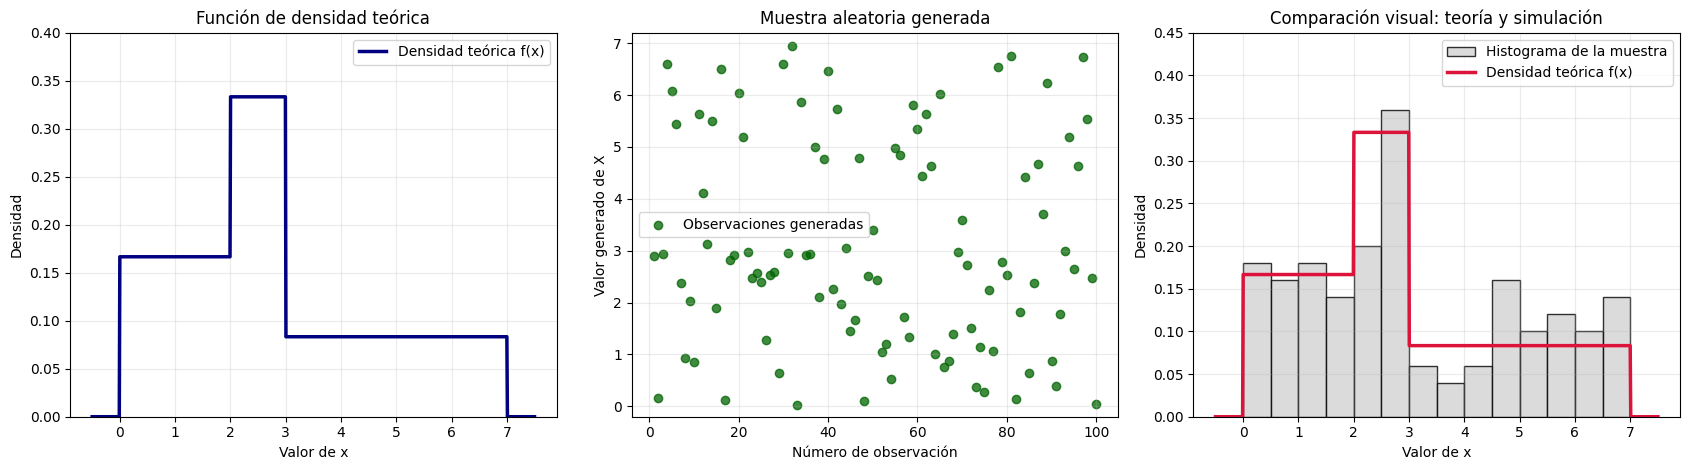

In [8]:
x_grid = np.linspace(-0.5, 7.5, 800)
density_grid = theoretical_pdf(x_grid)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(x_grid, density_grid, color="navy", linewidth=2.5, label="Densidad teórica f(x)")
axes[0].set_title("Función de densidad teórica")
axes[0].set_xlabel("Valor de x")
axes[0].set_ylabel("Densidad")
axes[0].set_ylim(0, 0.40)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(np.arange(1, sample_size + 1), sample, color="darkgreen", alpha=0.75, label="Observaciones generadas")
axes[1].set_title("Muestra aleatoria generada")
axes[1].set_xlabel("Número de observación")
axes[1].set_ylabel("Valor generado de X")
axes[1].set_ylim(-0.2, 7.2)
axes[1].grid(alpha=0.25)
axes[1].legend()

hist_bins = np.linspace(0, 7, 15)
axes[2].hist(sample, bins=hist_bins, density=True, color="lightgray", edgecolor="black", alpha=0.80, label="Histograma de la muestra")
axes[2].plot(x_grid, density_grid, color="crimson", linewidth=2.5, label="Densidad teórica f(x)")
axes[2].set_title("Comparación visual: teoría y simulación")
axes[2].set_xlabel("Valor de x")
axes[2].set_ylabel("Densidad")
axes[2].set_ylim(0, 0.45)
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()

# 4. Análisis comparativo entre la función f(x) y la muestra generada

La función de densidad teórica asigna la misma probabilidad total a cada uno de los tres intervalos principales:

- En $[0,2)$, la probabilidad esperada es $1/3$.
- En $[2,3)$, la probabilidad esperada es $1/3$.
- En $[3,7)$, la probabilidad esperada es $1/3$.

Aunque las probabilidades por intervalo son iguales, la altura de la densidad no es igual en todos los tramos porque los intervalos tienen longitudes diferentes. El intervalo $[2,3)$ es más corto, por eso su densidad es mayor.

In [9]:
interval_labels = ["[0, 2)", "[2, 3)", "[3, 7)"]
interval_counts = [
    np.sum((sample >= 0) & (sample < 2)),
    np.sum((sample >= 2) & (sample < 3)),
    np.sum((sample >= 3) & (sample < 7))
]

comparison_df = pd.DataFrame({
    "Intervalo": interval_labels,
    "Probabilidad teórica": [1/3, 1/3, 1/3],
    "Frecuencia absoluta simulada": interval_counts,
    "Frecuencia relativa simulada": np.array(interval_counts) / sample_size
})

comparison_df["Diferencia absoluta"] = (
    comparison_df["Frecuencia relativa simulada"] - comparison_df["Probabilidad teórica"]
).abs()

comparison_df

,Intervalo,Probabilidad teórica,Frecuencia absoluta simulada,Frecuencia relativa simulada,Diferencia absoluta
0,"[0, 2)",0.333333,33,0.33,0.003333
1,"[2, 3)",0.333333,28,0.28,0.053333
2,"[3, 7)",0.333333,39,0.39,0.056667


In [10]:
theoretical_mean = 17 / 6
simulated_mean = np.mean(sample)

mean_comparison = pd.DataFrame({
    "Medida": ["Media teórica", "Media simulada", "Diferencia absoluta"],
    "Valor": [theoretical_mean, simulated_mean, abs(simulated_mean - theoretical_mean)]
})

mean_comparison

,Medida,Valor
0,Media teórica,2.833333
1,Media simulada,3.109402
2,Diferencia absoluta,0.276069


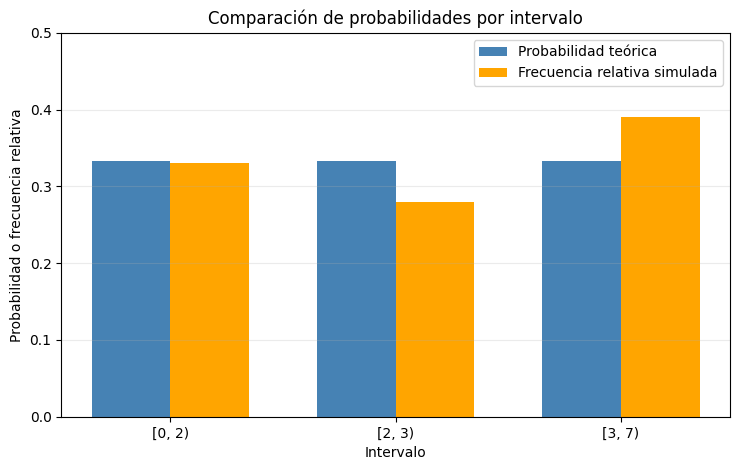

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

bar_positions = np.arange(len(interval_labels))
bar_width = 0.35

ax.bar(
    bar_positions - bar_width / 2,
    comparison_df["Probabilidad teórica"],
    width=bar_width,
    color="steelblue",
    label="Probabilidad teórica"
)
ax.bar(
    bar_positions + bar_width / 2,
    comparison_df["Frecuencia relativa simulada"],
    width=bar_width,
    color="orange",
    label="Frecuencia relativa simulada"
)

ax.set_title("Comparación de probabilidades por intervalo")
ax.set_xlabel("Intervalo")
ax.set_ylabel("Probabilidad o frecuencia relativa")
ax.set_xticks(bar_positions)
ax.set_xticklabels(interval_labels)
ax.set_ylim(0, 0.50)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

La muestra generada conserva la estructura general de la distribución teórica: los valores aparecen dentro del intervalo $[0,7)$, y cada uno de los tres tramos principales recibe una proporción cercana a $1/3$. Sin embargo, las frecuencias simuladas no tienen que coincidir exactamente con las probabilidades teóricas, porque la muestra tiene solo 100 observaciones.

Las diferencias entre la teoría y la simulación se deben a la variabilidad aleatoria propia del experimento. Cada ejecución genera números pseudoaleatorios uniformes que, al transformarse mediante $F^{-1}$, producen observaciones con la distribución deseada, pero no garantizan proporciones exactas en muestras pequeñas.

La media teórica es:

$$
E(X)=\int_0^2 \frac{x}{6}\, dx + \int_2^3 \frac{x}{3}\, dx + \int_3^7 \frac{x}{12}\, dx = \frac{17}{6}\approx 2.8333
$$

La media simulada puede ser diferente, pero debe ubicarse razonablemente cerca de la media teórica. Al aumentar el tamaño de la muestra, se espera que la media simulada se acerque más a $E(X)$.

# 5. Conclusiones del análisis comparativo

El generador construido mediante el método de la transformada inversa funciona correctamente, porque utiliza la función de distribución acumulada de la variable aleatoria y su inversa por tramos para transformar números uniformes en observaciones de $X$.

La muestra aleatoria generada se aproxima a la distribución teórica. Visualmente, el histograma presenta mayor concentración relativa en el tramo $[2,3)$, donde la densidad es más alta, y distribuye observaciones en los tres intervalos principales de acuerdo con la estructura esperada de la función $f(x)$.

Las diferencias entre las probabilidades teóricas y las frecuencias relativas simuladas son esperables porque se trabajó con una muestra de solo 100 observaciones. En muestras pequeñas, la variabilidad aleatoria puede producir diferencias visibles entre los valores simulados y los valores teóricos.

Si se aumentara el tamaño de la muestra, las frecuencias relativas de los intervalos tenderían a acercarse a las probabilidades teóricas de $1/3$, y la media simulada tendería a aproximarse más a la media teórica $17/6$. Esto es consistente con la ley de los grandes números.